# Pair Selection

Selects the top cointegrated, mean-reverting pairs from the ETF universe.

**All analysis uses IN-SAMPLE data only (2020-01-01 to 2023-12-31).**
The selected pairs and their hedge ratios are frozen and applied unchanged to OOS data.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from src.feature_engineering import hurst_exponent

# Reproducibility
np.random.seed(42)

In [2]:
# ── IN-SAMPLE BOUNDARY ──────────────────────────────────────────────────────
IS_END = '2023-12-31'  # pair selection uses data up to and including this date
# ────────────────────────────────────────────────────────────────────────────

prices_all = pd.read_csv('../data_raw/prices.csv', index_col=0, parse_dates=True)

# IN-SAMPLE slice only
prices_is = prices_all.loc[:IS_END].copy()

# Drop tickers that have >10% missing days in-sample
coverage = 1 - prices_is.isnull().mean()
keep = coverage[coverage >= 0.90].index.tolist()
dropped = set(prices_all.columns) - set(keep)
if dropped:
    print(f"Dropped due to <90% in-sample coverage: {dropped}")

prices_is = prices_is[keep].dropna()  # row-wise drop remaining NaNs
TICKERS = sorted(prices_is.columns.tolist())

print(f"In-sample period: {prices_is.index[0].date()} to {prices_is.index[-1].date()}")
print(f"Tickers in universe: {len(TICKERS)}")
print(f"Trading days: {len(prices_is)}")

In-sample period: 2020-01-02 to 2023-12-29
Tickers in universe: 40
Trading days: 1006


In [3]:
def johansen_test(p1: pd.Series, p2: pd.Series):
    """
    Run Johansen trace test on log prices of two ETFs.
    Returns (trace_stat, cv_95, is_cointegrated, hedge_ratio_vec).
    hedge_ratio_vec is the first eigenvector [w1, w2] normalised so w1=1.
    """
    log_df = pd.DataFrame({'p1': np.log(p1), 'p2': np.log(p2)}).dropna()
    try:
        result = coint_johansen(log_df, det_order=0, k_ar_diff=1)
    except Exception:
        return np.nan, np.nan, False, None

    trace_stat = result.lr1[0]          # trace statistic at r=0
    cv_95 = result.cvt[0, 1]            # 95% critical value at r=0
    is_coint = bool(trace_stat > cv_95)

    # First eigenvector gives the cointegrating weights
    evec = result.evec[:, 0]            # shape (2,)
    # Normalise so the first weight = 1
    evec = evec / evec[0]

    return trace_stat, cv_95, is_coint, evec


def compute_spread(p1: pd.Series, p2: pd.Series, evec):
    """Spread = log(p1)*evec[0] + log(p2)*evec[1] (Johansen linear combination)."""
    return np.log(p1) * evec[0] + np.log(p2) * evec[1]


def ou_half_life(spread: pd.Series):
    """
    Ornstein-Uhlenbeck half-life via OLS:
        delta_s = alpha + beta * s_{t-1} + eps
    half_life = -ln(2) / beta   (requires beta < 0 for MR)
    """
    delta_s = spread.diff().dropna()
    s_lag = spread.shift(1).dropna()
    idx = delta_s.index.intersection(s_lag.index)
    res = OLS(delta_s.loc[idx].values, add_constant(s_lag.loc[idx].values)).fit()
    beta = res.params[1]
    if beta >= 0:
        return np.nan   # not mean-reverting
    return -np.log(2) / beta

In [4]:
# Scan all C(N,2) candidate pairs on IN-SAMPLE data
HURST_MAX_LAG = 100
pairs = list(combinations(TICKERS, 2))
print(f"Candidate pairs: {len(pairs)}")

records = []

for i, (t1, t2) in enumerate(pairs):
    p1 = prices_is[t1]
    p2 = prices_is[t2]

    trace_stat, cv_95, is_coint, evec = johansen_test(p1, p2)

    if not is_coint or evec is None:
        continue

    spread = compute_spread(p1, p2, evec)

    H = hurst_exponent(spread.values, max_lag=HURST_MAX_LAG)
    if H >= 0.5:
        continue

    hl = ou_half_life(spread)

    records.append({
        'ticker1': t1,
        'ticker2': t2,
        'trace_stat': round(trace_stat, 2),
        'cv_95': round(cv_95, 2),
        'johansen_excess': round(trace_stat - cv_95, 2),
        'hurst': round(H, 4),
        'half_life_days': round(hl, 1) if not np.isnan(hl) else np.nan,
        'evec0': evec[0],
        'evec1': evec[1],
    })

results = pd.DataFrame(records)
print(f"\nPairs passing Johansen + Hurst filters: {len(results)}")

Candidate pairs: 780



Pairs passing Johansen + Hurst filters: 177


In [5]:
# Rank by half-life (ascending = faster mean-reversion = more tradeable)
# Drop pairs where OU half-life is NaN or implausibly long (>252 days)
valid = results.dropna(subset=['half_life_days'])
valid = valid[valid['half_life_days'] <= 252].copy()
valid = valid.sort_values('half_life_days').reset_index(drop=True)

N_PAIRS = 15
selected = valid.head(N_PAIRS).copy()
selected.index = range(1, len(selected) + 1)

display_cols = ['ticker1', 'ticker2', 'trace_stat', 'cv_95', 'johansen_excess', 'hurst', 'half_life_days']
print(f"Top {N_PAIRS} selected pairs (ranked by OU half-life):")
print(selected[display_cols].to_string())

Top 15 selected pairs (ranked by OU half-life):
   ticker1 ticker2  trace_stat  cv_95  johansen_excess   hurst  half_life_days
1      EWJ     HYG       51.68  15.49            36.19  0.1629            12.9
2      HYG     XLC       31.50  15.49            16.01  0.2318            17.0
3      XLU     XOP       18.15  15.49             2.65  0.2486            19.0
4      HYG    MTUM       27.63  15.49            12.14  0.2342            19.9
5      EWC     IWD       16.49  15.49             0.99  0.3108            19.9
6     GDXJ     LQD       19.14  15.49             3.64  0.3982            20.1
7      USO     XLU       29.76  15.49            14.26  0.2532            20.2
8      EWG     HYG       33.28  15.49            17.79  0.2579            20.5
9      EWJ     XLC       24.66  15.49             9.17  0.3341            20.8
10     EWC     XLF       17.10  15.49             1.61  0.3928            21.9
11    GDXJ     USO       28.16  15.49            12.67  0.3663            22.5
12  

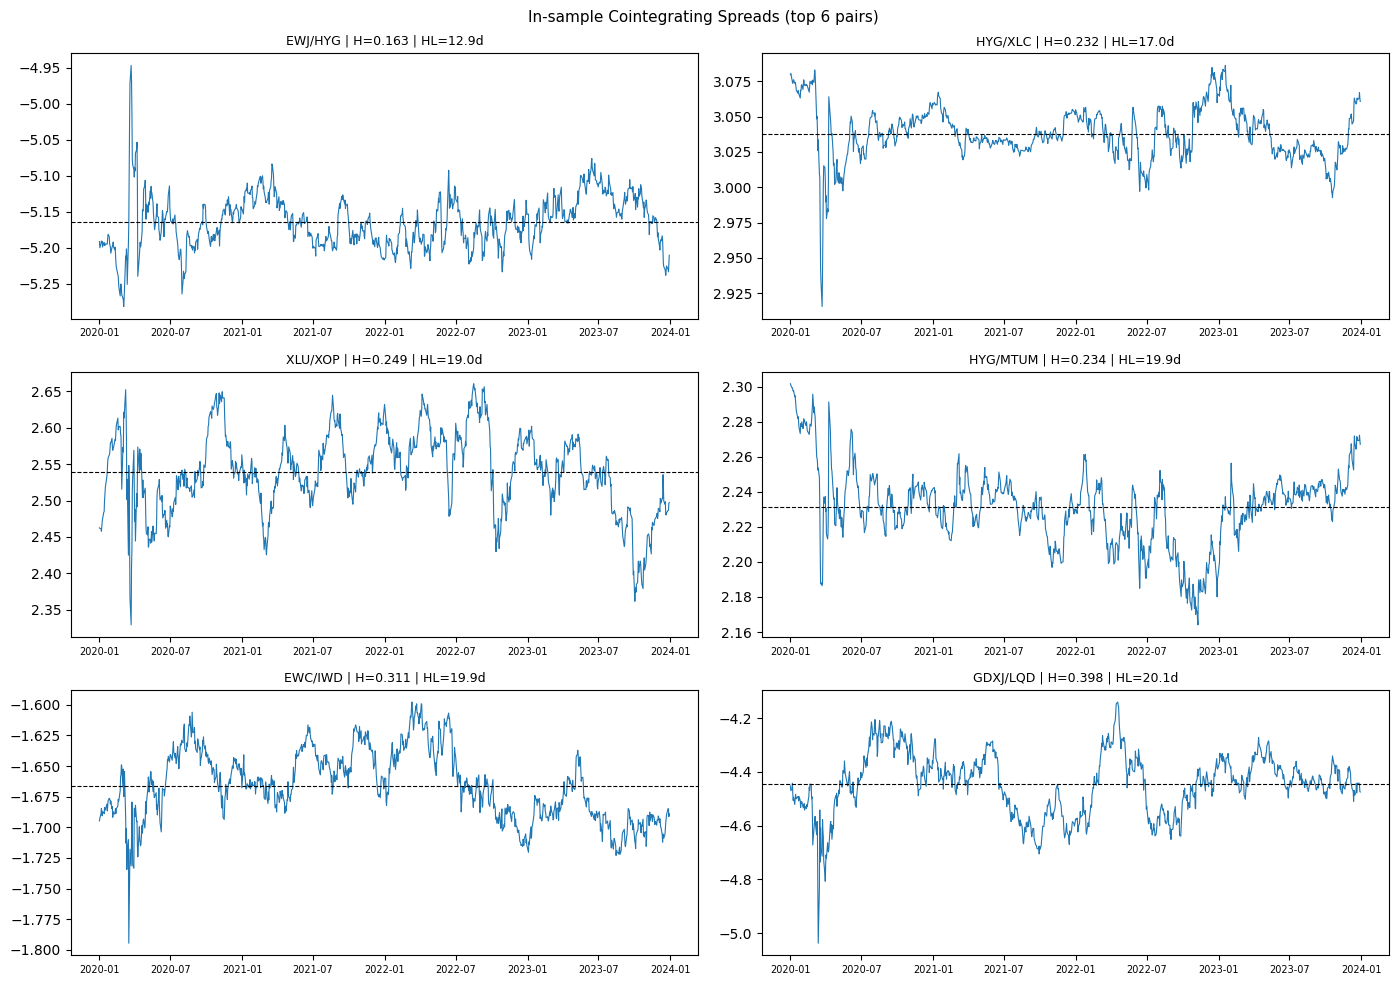

Saved spread_plots.png


In [6]:
# Visual sanity check: plot in-sample spreads for top 6 pairs
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, row in selected.head(6).iterrows():
    t1, t2 = row['ticker1'], row['ticker2']
    evec = np.array([row['evec0'], row['evec1']])
    spread_is = compute_spread(prices_is[t1], prices_is[t2], evec)

    ax = axes[idx - 1]
    ax.plot(spread_is.index, spread_is.values, lw=0.8)
    ax.axhline(spread_is.mean(), color='black', linestyle='--', lw=0.8)
    ax.set_title(f"{t1}/{t2} | H={row['hurst']:.3f} | HL={row['half_life_days']:.1f}d", fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=7)

plt.suptitle('In-sample Cointegrating Spreads (top 6 pairs)', fontsize=11)
plt.tight_layout()
plt.savefig('../data_processed/spread_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved spread_plots.png")

In [7]:
# Save selected pairs metadata for downstream notebooks
# Includes hedge ratio vectors (estimated on in-sample data only)
selected.to_csv('../data_processed/selected_pairs.csv')
print("Saved selected_pairs.csv")
print(selected[display_cols])

Saved selected_pairs.csv
   ticker1 ticker2  trace_stat  cv_95  johansen_excess   hurst  half_life_days
1      EWJ     HYG       51.68  15.49            36.19  0.1629            12.9
2      HYG     XLC       31.50  15.49            16.01  0.2318            17.0
3      XLU     XOP       18.15  15.49             2.65  0.2486            19.0
4      HYG    MTUM       27.63  15.49            12.14  0.2342            19.9
5      EWC     IWD       16.49  15.49             0.99  0.3108            19.9
6     GDXJ     LQD       19.14  15.49             3.64  0.3982            20.1
7      USO     XLU       29.76  15.49            14.26  0.2532            20.2
8      EWG     HYG       33.28  15.49            17.79  0.2579            20.5
9      EWJ     XLC       24.66  15.49             9.17  0.3341            20.8
10     EWC     XLF       17.10  15.49             1.61  0.3928            21.9
11    GDXJ     USO       28.16  15.49            12.67  0.3663            22.5
12     XLP     XLV       24